In [2]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import pandas as pd


In [3]:
#Como se ve los datos de ACT, que son los de actividades a nivel nacional, pero los datos sacados de SERNATUR, vienen en un 
# excel, de distintas hojas, se busco la hoja de las actividades a nivel comunal y los valores en UF, y se guardo de forma .csv 
# link de acceso: https://drive.google.com/file/d/1o1lp7bbChpzDCOPK0fUWyKxNnvd7_Hwz/view?usp=sharing

file_id_encuesta = "1o1lp7bbChpzDCOPK0fUWyKxNnvd7_Hwz"

url = f"https://drive.google.com/uc?id={file_id_encuesta}"

ventas_actividad = pd.read_csv(
    url,
    sep=";",
    engine="python"
)

# Para el análisis del proyecto se trabaja únicamente con información de San Fernando
# correspondiente al año comercial 2025.
ventas_actividad = ventas_actividad[
    (ventas_actividad["Año Comercial"] == 2025) &
    (
        ventas_actividad["Comuna del domicilio o casa matriz"]
        .astype(str)
        .str.strip()
        .str.lower()
        .eq("san fernando")
    )
].copy()

ventas_actividad.head(5)


,Año Comercial,Region del domicilio o casa matriz,Provincia del domicilio o casa matriz,Comuna del domicilio o casa matriz,Actividad economica,Glosa actividad economica,Número de empresas,Ventas anuales en UF,Trabajadores dependientes informados ponderados,Renta neta informada,Trabajadores a honorarios ponderados por meses trabajados,Honorarios pagados informados,COD_ACT,ACT,CUT_comuna,ACT Prioritaria,Unnamed: 16
0,2012,Región de Tarapacá,Iquique,Iquique,551001,Actividades de hoteles,85.0,"516.282,96","515,166","68.130,9550",166,"16.350,792",1,Alojamiento turístico,1101,SI,NaN
1,2012,Región de Tarapacá,Iquique,Iquique,551002,Actividades de moteles,3.0,*,"5,750",*,2,*,1,Alojamiento turístico,1101,SI,NaN
2,2012,Región de Tarapacá,Iquique,Iquique,559001,Actividades de residenciales para estudiantes ...,81.0,"75.200,78","84,417","5.989,1840",48,"3.211,949",1,Alojamiento turístico,1101,NO,NaN
3,2012,Región de Tarapacá,Iquique,Iquique,559009,Otras actividades de alojamiento n.c.p.,22.0,"59.725,64","60,250","6.684,3820",59,"8.392,627",1,Alojamiento turístico,1101,SI,NaN
4,2012,Región de Tarapacá,Iquique,Iquique,561000,Actividades de restaurantes y de servicio móvi...,406.0,"1.084.098,49","1.080,583","89.823,7840",231,"14.714,293",2,Actividades de provisión de alimentos y bebidas,1101,SI,NaN


### Alcance del análisis

Desde el inicio se filtra la base para trabajar únicamente con registros de **San Fernando** y del **año comercial 2025**. De esta forma, los cálculos posteriores se enfocan directamente en la comuna y período relevantes para el proyecto, manteniendo sin cambios el resto del flujo de análisis.


In [5]:
ventas_actividad.columns

Index(['Año Comercial', 'Region del domicilio o casa matriz',
       'Provincia del domicilio o casa matriz',
       'Comuna del domicilio o casa matriz', 'Actividad economica',
       'Glosa actividad economica', 'Número de empresas',
       'Ventas anuales en UF',
       'Trabajadores dependientes informados ponderados',
       'Renta neta informada',
       'Trabajadores a honorarios ponderados por meses trabajados',
       'Honorarios pagados informados', 'COD_ACT', 'ACT', 'CUT_comuna',
       'ACT Prioritaria', 'Unnamed: 16'],
      dtype='object')

Se revisa la estructura general del dataset para identificar su tamaño, tipos de variables y posibles columnas con información incompleta antes de iniciar el análisis de calidad.

In [ ]:
# Tamaño de la tabla
print("Dimensiones:", ventas_actividad.shape)

# Tipos de datos y valores no nulos
ventas_actividad.info()

Dimensiones: (90234, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90234 entries, 0 to 90233
Data columns (total 17 columns):
 #   Column                                                     Non-Null Count  Dtype  
---  ------                                                     --------------  -----  
 0   Año Comercial                                              90234 non-null  int64  
 1   Region del domicilio o casa matriz                         90234 non-null  object 
 2   Provincia del domicilio o casa matriz                      90234 non-null  object 
 3   Comuna del domicilio o casa matriz                         90234 non-null  object 
 4   Actividad economica                                        90234 non-null  int64  
 5   Glosa actividad economica                                  90234 non-null  object 
 6   Número de empresas                                         90234 non-null  float64
 7   Ventas anuales en UF                                       90234 non-

La base contiene 90.234 registros y 17 variables. Se identificó una columna completamente vacía (Unnamed: 16) y varias variables cuantitativas almacenadas como texto, por lo que será necesario revisar su formato antes de realizar análisis descriptivos.

In [7]:
# Valores faltantes por columna
faltantes = ventas_actividad.isna().sum().sort_values(ascending=False)

faltantes

Unnamed: 16                                                  90234
Año Comercial                                                    0
Region del domicilio o casa matriz                               0
Comuna del domicilio o casa matriz                               0
Provincia del domicilio o casa matriz                            0
Glosa actividad economica                                        0
Número de empresas                                               0
Ventas anuales en UF                                             0
Actividad economica                                              0
Trabajadores dependientes informados ponderados                  0
Renta neta informada                                             0
Honorarios pagados informados                                    0
Trabajadores a honorarios ponderados por meses trabajados        0
COD_ACT                                                          0
ACT                                                           

La revisión de valores faltantes muestra que todas las variables relevantes están completas. La columna Unnamed: 16 contiene únicamente valores nulos, por lo que corresponde a una columna residual del archivo y será eliminada para efectos de analisis.

In [8]:
# Eliminar columna completamente vacía
ventas_actividad = ventas_actividad.drop(columns=["Unnamed: 16"])

In [9]:
ventas_actividad.columns

Index(['Año Comercial', 'Region del domicilio o casa matriz',
       'Provincia del domicilio o casa matriz',
       'Comuna del domicilio o casa matriz', 'Actividad economica',
       'Glosa actividad economica', 'Número de empresas',
       'Ventas anuales en UF',
       'Trabajadores dependientes informados ponderados',
       'Renta neta informada',
       'Trabajadores a honorarios ponderados por meses trabajados',
       'Honorarios pagados informados', 'COD_ACT', 'ACT', 'CUT_comuna',
       'ACT Prioritaria'],
      dtype='object')

In [10]:
# Revisar filas duplicadas
duplicados = ventas_actividad.duplicated().sum()

print("Cantidad de filas duplicadas:", duplicados)

Cantidad de filas duplicadas: 0


In [11]:
columnas_numericas_texto = [
    "Ventas anuales en UF",
    "Trabajadores dependientes informados ponderados",
    "Renta neta informada",
    "Trabajadores a honorarios ponderados por meses trabajados",
    "Honorarios pagados informados"
]

for col in columnas_numericas_texto:
    valores_no_numericos = ventas_actividad[
        pd.to_numeric(
            ventas_actividad[col]
            .astype(str)
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).isna()
    ][col].value_counts()

    print(f"\n{col}:")
    print(valores_no_numericos.head(10))


Ventas anuales en UF:
Ventas anuales en UF
*    62628
Name: count, dtype: int64

Trabajadores dependientes informados ponderados:
Series([], Name: count, dtype: int64)

Renta neta informada:
Renta neta informada
*    62628
Name: count, dtype: int64

Trabajadores a honorarios ponderados por meses trabajados:
Series([], Name: count, dtype: int64)

Honorarios pagados informados:
Honorarios pagados informados
*    62628
Name: count, dtype: int64


In [12]:
cols_asterisco = [
    "Ventas anuales en UF",
    "Renta neta informada",
    "Honorarios pagados informados"
]

# Revisar cuántas filas tienen asterisco en cada combinación
ventas_actividad[cols_asterisco].eq("*").value_counts()

Ventas anuales en UF  Renta neta informada  Honorarios pagados informados
True                  True                  True                             62628
False                 False                 False                            27606
Name: count, dtype: int64

Se detectó el valor * en tres variables económicas. Dado que su significado debe ser verificado antes de interpretarlo como dato faltante, estos registros se mantienen sin modificación en esta etapa.

In [13]:
ventas_actividad.groupby(
    ventas_actividad["Ventas anuales en UF"].eq("*")
)["Número de empresas"].describe()

,count,mean,std,min,25%,50%,75%,max
Ventas anuales en UF,,,,,,,,
False,27606.0,59.720968,104.193876,1.008,16.0,27.0,58.0,4698.0
True,62628.0,3.324248,2.581374,1.000,1.0,2.0,5.0,10.0


Los registros con * se concentran en actividades con un bajo número de empresas: presentan una mediana de 2 empresas y un máximo de 10. Esto sugiere que el símbolo podría estar asociado a una regla de resguardo de información para actividades con pocos registros, por lo que se mantendrá como valor especial hasta verificar su definición en la fuente.

In [14]:
columnas_convertir = [
    "Número de empresas",
    "Trabajadores dependientes informados ponderados",
    "Trabajadores a honorarios ponderados por meses trabajados"
]

for col in columnas_convertir:
    ventas_actividad[col] = (
        ventas_actividad[col]
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    ventas_actividad[col] = pd.to_numeric(
        ventas_actividad[col],
        errors="coerce"
    )

In [15]:
ventas_actividad[columnas_convertir].dtypes

Número de empresas                                             int64
Trabajadores dependientes informados ponderados              float64
Trabajadores a honorarios ponderados por meses trabajados    float64
dtype: object

In [16]:
ventas_actividad[columnas_convertir].isna().sum()

Número de empresas                                           0
Trabajadores dependientes informados ponderados              0
Trabajadores a honorarios ponderados por meses trabajados    0
dtype: int64

Se convierten a formato numérico las variables cuantitativas que no presentan valores especiales, con el fin de habilitar su análisis descriptivo y evitar interpretaciones incorrectas derivadas del formato de texto.

In [17]:
columnas_con_asterisco = [
    "Ventas anuales en UF",
    "Renta neta informada",
    "Honorarios pagados informados"
]

for col in columnas_con_asterisco:
    ventas_actividad[col + "_num"] = (
        ventas_actividad[col]
        .replace("*", np.nan)
        .astype(str)
        .str.replace(".", "", regex=False)
        .str.replace(",", ".", regex=False)
    )

    ventas_actividad[col + "_num"] = pd.to_numeric(
        ventas_actividad[col + "_num"],
        errors="coerce"
    )

In [18]:
ventas_actividad[
    [col + "_num" for col in columnas_con_asterisco]
].dtypes

Ventas anuales en UF_num             float64
Renta neta informada_num             float64
Honorarios pagados informados_num    float64
dtype: object

In [19]:
ventas_actividad[
    [col + "_num" for col in columnas_con_asterisco]
].isna().sum()

Ventas anuales en UF_num             62628
Renta neta informada_num             62628
Honorarios pagados informados_num    62628
dtype: int64

Para facilitar el análisis estadístico, se crearon versiones numéricas de las variables económicas, reemplazando temporalmente los valores * por NaN. Las columnas originales se conservan sin modificación.

In [20]:
variables_analisis = [
    "Número de empresas",
    "Ventas anuales en UF_num",
    "Trabajadores dependientes informados ponderados",
    "Renta neta informada_num",
    "Trabajadores a honorarios ponderados por meses trabajados",
    "Honorarios pagados informados_num"
]

resumen = pd.DataFrame({
    "media": ventas_actividad[variables_analisis].mean(),
    "mediana": ventas_actividad[variables_analisis].median(),
    "moda": ventas_actividad[variables_analisis].mode().iloc[0],
    "desviacion_std": ventas_actividad[variables_analisis].std()
})

resumen.round(2)

,media,mediana,moda,desviacion_std
Número de empresas,207.71,40.00,10.0,635.82
Ventas anuales en UF_num,546656.67,29756.66,0.0,5629307.73
Trabajadores dependientes informados ponderados,52.49,1.00,0.0,484.46
Renta neta informada_num,39041.10,2260.11,0.0,253231.78
Trabajadores a honorarios ponderados por meses trabajados,13.39,1.00,0.0,98.19
Honorarios pagados informados_num,6320.24,469.01,0.0,34452.98


Las variables económicas y laborales presentan una marcada dispersión y diferencias importantes entre media y mediana, lo que sugiere distribuciones asimétricas influenciadas por registros con valores altos.

In [21]:
ventas_actividad[variables_analisis].skew().round(2)

Número de empresas                                           13.28
Ventas anuales en UF_num                                     31.82
Trabajadores dependientes informados ponderados              32.91
Renta neta informada_num                                     17.77
Trabajadores a honorarios ponderados por meses trabajados    48.36
Honorarios pagados informados_num                            17.11
dtype: float64

Las variables analizadas presentan una fuerte asimetría positiva, lo que indica una alta concentración de registros en valores bajos y la presencia de pocos casos con valores considerablemente altos.

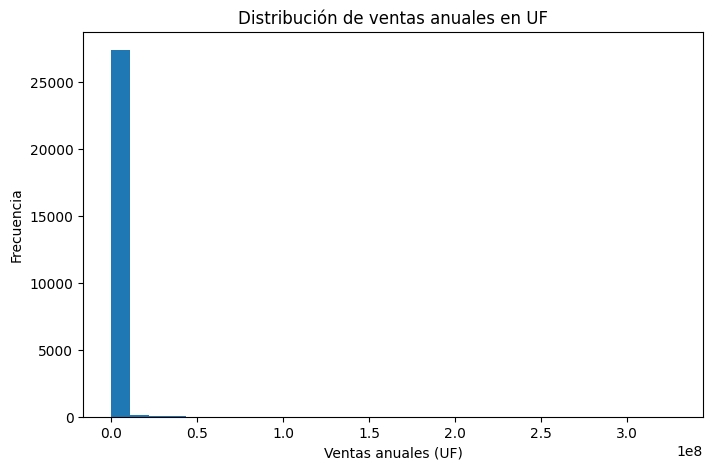

In [22]:
plt.figure(figsize=(8, 5))

plt.hist(
    ventas_actividad["Ventas anuales en UF_num"].dropna(),
    bins=30
)

plt.title("Distribución de ventas anuales en UF")
plt.xlabel("Ventas anuales (UF)")
plt.ylabel("Frecuencia")

plt.show()

La distribución de ventas anuales presenta una fuerte concentración en valores bajos y una cola extensa hacia valores altos. Para facilitar su visualización, se utiliza una escala logarítmica en el eje de ventas.

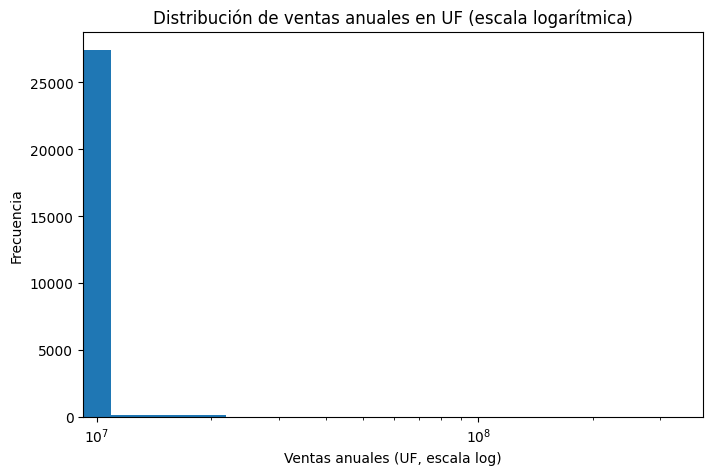

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    ventas_actividad["Ventas anuales en UF_num"].dropna(),
    bins=30
)

plt.xscale("log")

plt.title("Distribución de ventas anuales en UF (escala logarítmica)")
plt.xlabel("Ventas anuales (UF, escala log)")
plt.ylabel("Frecuencia")

plt.show()

La variable de ventas anuales presenta una fuerte asimetría positiva y una concentración marcada en valores relativamente bajos, incluso al utilizar escala logarítmica. Esto evidencia la presencia de algunos registros con ventas considerablemente superiores al resto.

In [24]:
ventas_actividad.nlargest(
    10,
    "Ventas anuales en UF_num"
)[
    [
        "Año Comercial",
        "Comuna del domicilio o casa matriz",
        "Glosa actividad economica",
        "Número de empresas",
        "Ventas anuales en UF_num"
    ]
]

,Año Comercial,Comuna del domicilio o casa matriz,Glosa actividad economica,Número de empresas,Ventas anuales en UF_num
45949,2018,Quilicura,Alquiler de bienes inmuebles amoblados o con e...,1290,3.278997e+08
38153,2017,Quilicura,"Compra, venta y alquiler (excepto amoblados) d...",2010,3.157108e+08
30727,2016,Quilicura,"Compra, venta y alquiler (excepto amoblados) d...",1900,2.920943e+08
15992,2014,Santiago,Otras actividades de alojamiento n.c.p.,610,1.837932e+08
22776,2015,Santiago,Otras actividades de alojamiento n.c.p.,600,1.826505e+08
29978,2016,Santiago,Otras actividades de alojamiento n.c.p.,660,1.822926e+08
79281,2022,Las Condes,Transporte de pasajeros por vía aérea,470,1.762786e+08
37435,2017,Santiago,Alquiler de bienes inmuebles amoblados o con e...,6620,1.573619e+08
23507,2015,Quilicura,"Compra, venta y alquiler (excepto amoblados) d...",1320,1.555266e+08
45158,2018,Santiago,Actividades de agencias de viajes,2640,1.475130e+08


Los valores máximos de ventas corresponden a actividades económicas específicas en comunas de alta actividad empresarial, por lo que no se identifican como registros agregados ni errores evidentes. Estos casos explican parte de la fuerte asimetría observada en la distribución de ventas.

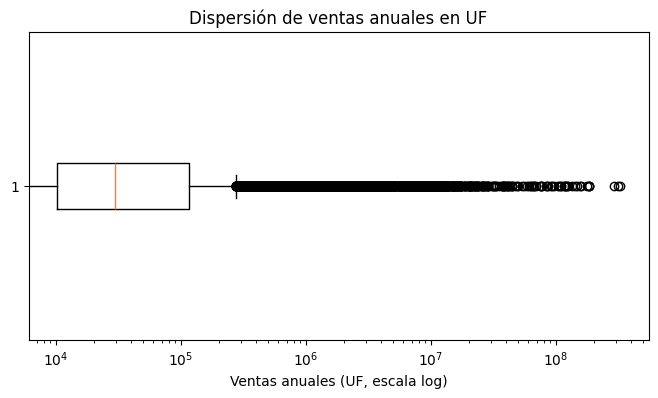

In [25]:
plt.figure(figsize=(8, 4))

plt.boxplot(
    ventas_actividad["Ventas anuales en UF_num"].dropna(),
    vert=False
)

plt.xscale("log")

plt.title("Dispersión de ventas anuales en UF")
plt.xlabel("Ventas anuales (UF, escala log)")

plt.show()

Las ventas anuales presentan una dispersión muy alta y numerosos valores extremos hacia la derecha. Incluso usando escala logarítmica, se mantiene una cola importante de observaciones con ventas muy superiores al rango central

In [26]:
corr_pearson = ventas_actividad[variables_analisis].corr(method="pearson")

corr_pearson.round(2)

,Número de empresas,Ventas anuales en UF_num,Trabajadores dependientes informados ponderados,Renta neta informada_num,Trabajadores a honorarios ponderados por meses trabajados,Honorarios pagados informados_num
Número de empresas,1.00,0.21,0.37,0.28,0.41,0.35
Ventas anuales en UF_num,0.21,1.00,0.40,0.66,0.32,0.48
Trabajadores dependientes informados ponderados,0.37,0.40,1.00,0.84,0.51,0.48
Renta neta informada_num,0.28,0.66,0.84,1.00,0.47,0.56
Trabajadores a honorarios ponderados por meses trabajados,0.41,0.32,0.51,0.47,1.00,0.85
Honorarios pagados informados_num,0.35,0.48,0.48,0.56,0.85,1.00


In [27]:
corr_spearman = ventas_actividad[variables_analisis].corr(method="spearman")

corr_spearman.round(2)

,Número de empresas,Ventas anuales en UF_num,Trabajadores dependientes informados ponderados,Renta neta informada_num,Trabajadores a honorarios ponderados por meses trabajados,Honorarios pagados informados_num
Número de empresas,1.00,0.68,0.69,0.62,0.75,0.58
Ventas anuales en UF_num,0.68,1.00,0.87,0.90,0.79,0.84
Trabajadores dependientes informados ponderados,0.69,0.87,1.00,0.97,0.75,0.78
Renta neta informada_num,0.62,0.90,0.97,1.00,0.78,0.83
Trabajadores a honorarios ponderados por meses trabajados,0.75,0.79,0.75,0.78,1.00,0.87
Honorarios pagados informados_num,0.58,0.84,0.78,0.83,0.87,1.00


Las correlaciones de Spearman son considerablemente mayores que las de Pearson en varias variables, lo que indica relaciones monotónicas fuertes afectadas por la asimetría y los valores extremos. Destacan las asociaciones entre ventas, renta neta y trabajadores dependientes, además de la relación entre trabajadores a honorarios y honorarios pagados.

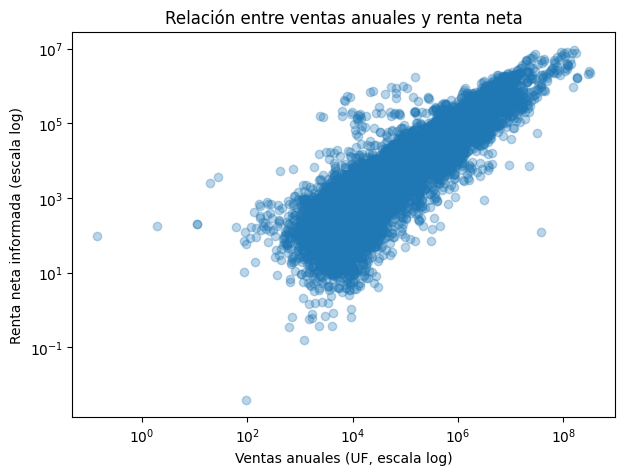

In [28]:
plt.figure(figsize=(7, 5))

plt.scatter(
    ventas_actividad["Ventas anuales en UF_num"],
    ventas_actividad["Renta neta informada_num"],
    alpha=0.3
)

plt.xscale("log")
plt.yscale("log")

plt.title("Relación entre ventas anuales y renta neta")
plt.xlabel("Ventas anuales (UF, escala log)")
plt.ylabel("Renta neta informada (escala log)")

plt.show()

El gráfico de dispersión muestra una relación positiva clara entre las ventas anuales y la renta neta informada. La tendencia es consistente con la alta correlación de Spearman observada entre ambas variables, aunque se mantiene una dispersión considerable entre los registros.